In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

In [9]:
image = cv2.imread('img.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

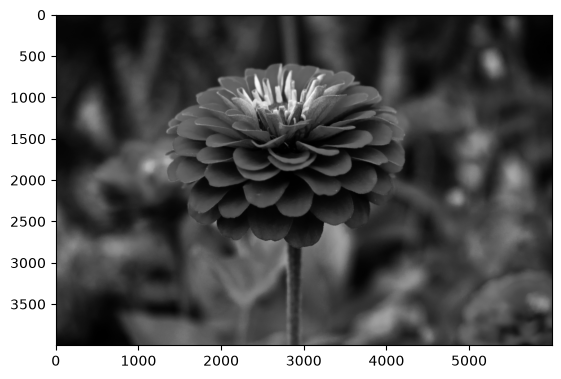

In [10]:
plt.imshow(image_gray, cmap="gray")

1. Зашумить изображение при помощи шума гаусса, постоянного шума.

In [11]:
#Gauss
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[100,  17,   0, ...,   0,   0,  22],
       [117,   0,   0, ...,  11,   0,  40],
       [137,   0,  91, ...,   6, 161,  51],
       ...,
       [ 34, 132,   0, ...,   0,   0,  70],
       [128,   0,   0, ...,   2,   0,   0],
       [150,  95,  84, ...,   0,   0,   0]],
      shape=(4000, 6000), dtype=uint8)

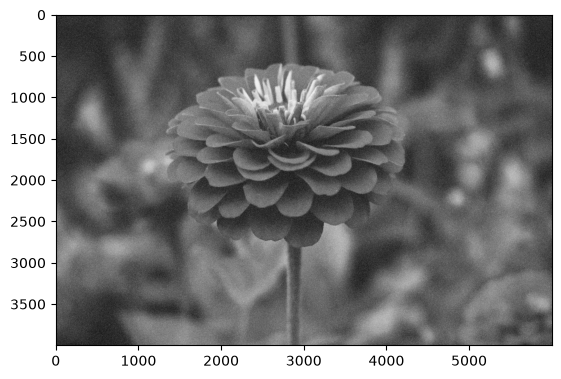

In [12]:
image_noise_gauss = cv2.add(image_gray,noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")

In [13]:
#Constant
np.random.seed(100)
a, b = 25, 125
noise_constant = np.random.uniform(a, b, image_gray.shape).astype(np.uint8)

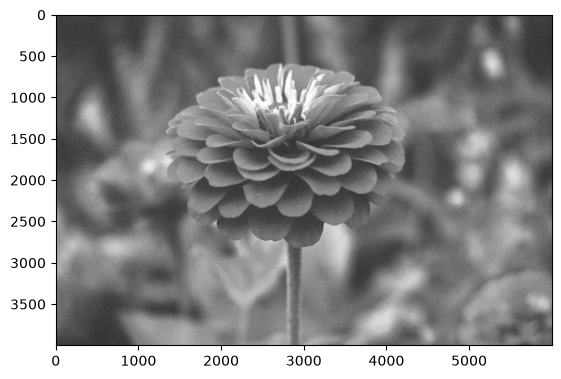

In [14]:
image_noise_constant = cv2.add(image_gray, noise_constant)
plt.imshow(image_noise_constant, cmap='gray')

2. Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

In [15]:
#MedianBlur
image_gauss_median=cv2.medianBlur(image_noise_gauss, 5)
image_constant_median=cv2.medianBlur(image_noise_constant, 5)

# GaussianBlur
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
image_constant_gauss = cv2.GaussianBlur(image_noise_constant, (5, 5), 0)

# bilateralFilter
image_gauss_bilateral = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
image_constant_bilateral = cv2.bilateralFilter(image_noise_constant, 9, 75, 75)

# fastNlMeansDenoising
image_gauss_nlm = cv2.fastNlMeansDenoising(image_noise_gauss, h=20)
image_constant_nlm = cv2.fastNlMeansDenoising(image_noise_constant, h=20)

Text(0.5, 1.0, 'Constant NLM h=20')

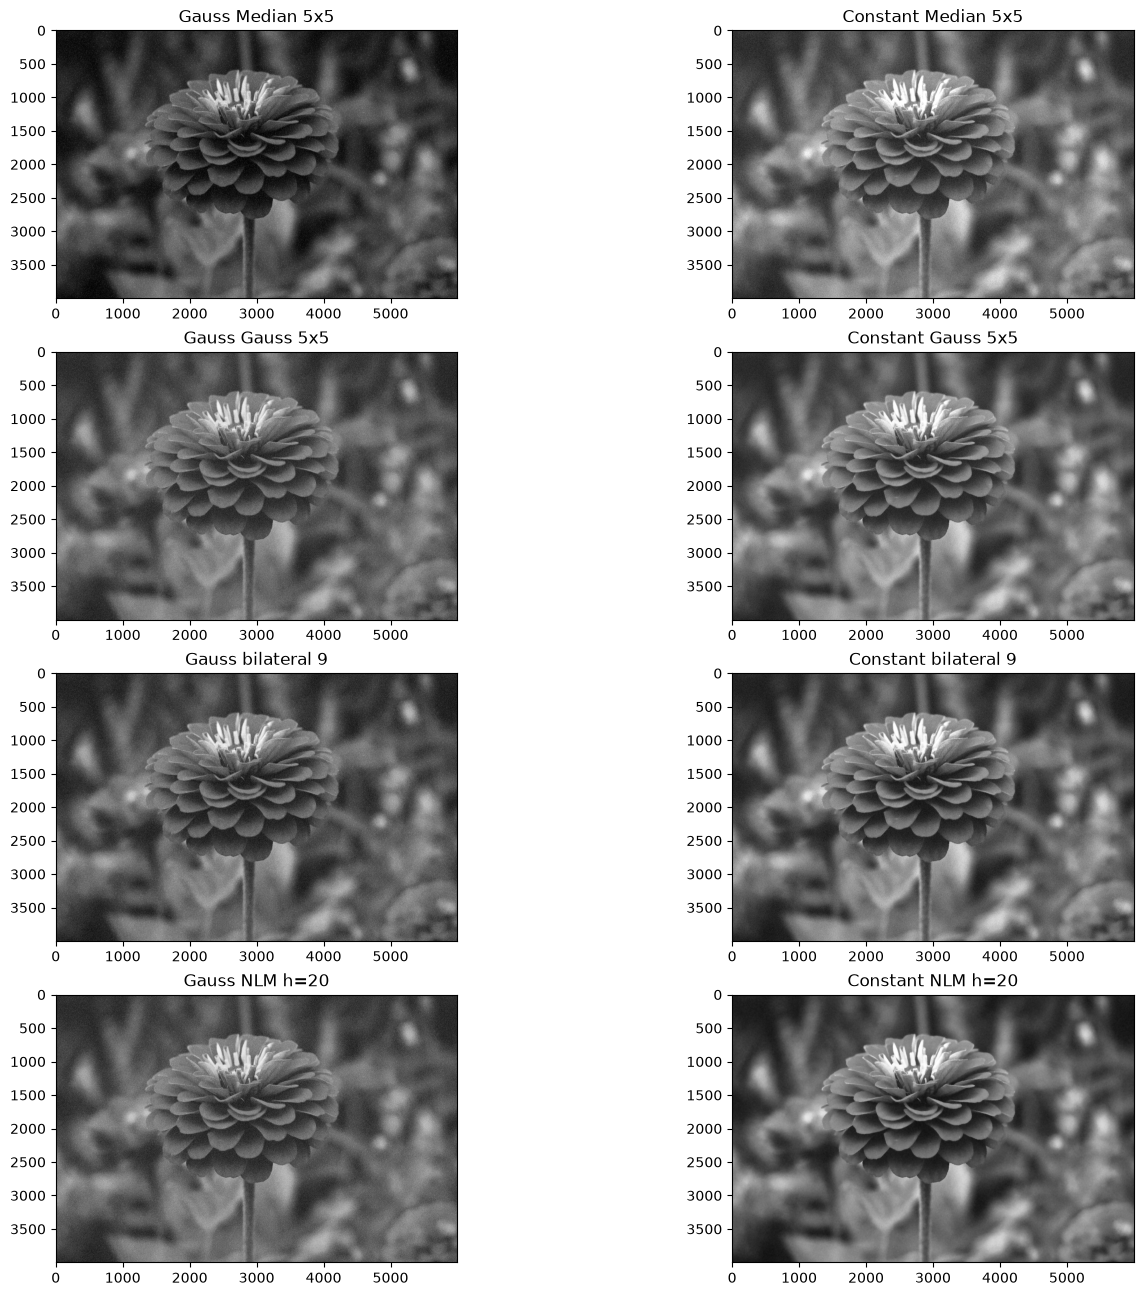

In [16]:
plt.figure(figsize=(16,16))
plt.subplot(4,2,1);plt.imshow(image_gauss_median, cmap='gray');plt.title("Gauss Median 5x5")
plt.subplot(4,2,2);plt.imshow(image_constant_median, cmap='gray');plt.title("Constant Median 5x5")
plt.subplot(4,2,3);plt.imshow(image_gauss_gauss, cmap='gray');plt.title("Gauss Gauss 5x5")
plt.subplot(4,2,4);plt.imshow(image_constant_gauss, cmap='gray');plt.title("Constant Gauss 5x5")
plt.subplot(4,2,5);plt.imshow(image_gauss_bilateral, cmap='gray');plt.title("Gauss bilateral 9")
plt.subplot(4,2,6);plt.imshow(image_constant_bilateral, cmap='gray');plt.title("Constant bilateral 9")
plt.subplot(4,2,7);plt.imshow(image_gauss_nlm, cmap='gray');plt.title("Gauss NLM h=20")
plt.subplot(4,2,8);plt.imshow(image_constant_nlm, cmap='gray');plt.title("Constant NLM h=20")

3. Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [17]:
gauss = [
    ('Median 5x5', image_gauss_median),
    ('Gauss 5x5', image_gauss_gauss),
    ('Bilateral 9', image_gauss_bilateral),
    ('NLM h=20', image_gauss_nlm)]
constant = [
    ('Median 5x5', image_constant_median),
    ('Gauss 5x5', image_constant_gauss),
    ('Bilateral 9', image_constant_bilateral),
    ('NLM h=20', image_constant_nlm)]

ssim_gauss = -1
ssim_constant = -1
mse_gauss = float('inf')
mse_constant = float('inf')

ssim_gauss_name = ''
ssim_constant_name = ''
mse_gauss_name = ''
mse_constant_name = ''

for name, img in gauss:
    ssim = structural_similarity(image_gray, img)
    mse = mean_squared_error(image_gray, img)
    print(f'Gauss {name}: SSIM({ssim}), MSE({mse})')
    if (ssim > ssim_gauss):
        ssim_gauss = ssim
        ssim_gauss_name = name
    if (mse < mse_gauss):
        mse_gauss = mse
        mse_gauss_name = name

print(f'\nBest for Gauss: SSIM({ssim_gauss}) - {ssim_gauss_name}, MSE({mse_gauss}) - {mse_gauss_name}\n')

for name, img in constant:
    ssim = structural_similarity(image_gray, img)
    mse = mean_squared_error(image_gray, img)
    print(f'Constant {name}: SSIM({ssim}), MSE({mse})')
    if (ssim > ssim_constant):
        ssim_constant = ssim
        ssim_constant_name = name
    if (mse < mse_constant):
        mse_constant = mse
        mse_constant_name = name

print(f'\nBest for Constant: SSIM({ssim_constant}) - {ssim_constant_name}, MSE({mse_constant}) - {mse_constant_name}')

Gauss Median 5x5: SSIM(0.3650009204383486), MSE(334.33491495833334)
Gauss Gauss 5x5: SSIM(0.23062714418614064), MSE(1730.9776904166667)
Gauss Bilateral 9: SSIM(0.10453307792372918), MSE(1788.7017316666668)
Gauss NLM h=20: SSIM(0.028943383879270024), MSE(4488.982999875)

Best for Gauss: SSIM(0.3650009204383486) - Median 5x5, MSE(334.33491495833334) - Median 5x5

Constant Median 5x5: SSIM(0.2963161031763846), MSE(5642.86398475)
Constant Gauss 5x5: SSIM(0.35365022580533284), MSE(5602.374839291667)
Constant Bilateral 9: SSIM(0.41992173932172616), MSE(5577.358854)
Constant NLM h=20: SSIM(0.40335476082865873), MSE(5577.706760375)

Best for Constant: SSIM(0.41992173932172616) - Bilateral 9, MSE(5577.358854) - Bilateral 9
